In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ConvNeXt_Tiny_Weights, ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ZIP_PATH = Path('/content/drive/MyDrive/NatDisaster/Roads.zip')


EXTRACT_DIR = Path('/content/RoadsData')
MODELS_DIR = Path('/content/drive/MyDrive/NatDisaster/models_roads')
RESULTS_DIR = Path('/content/drive/MyDrive/NatDisaster/results_roads')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'resnet50'  # options: 'convnext_tiny', 'resnet50'
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 12
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
print('Zip path:', ZIP_PATH)


Using device: cuda
Zip path: /content/drive/MyDrive/NatDisaster/Roads.zip


In [ ]:
assert ZIP_PATH.exists(), f'Could not find {ZIP_PATH}. Check the path and file name.'

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

print('Extracted to:', EXTRACT_DIR)
print('Top-level items:')
for p in sorted(EXTRACT_DIR.iterdir()):
    print('-', p.name)

Extracted to: /content/RoadsData
Top-level items:
- Roads_768
- __MACOSX


In [ ]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

CLASS_ALIASES = {
    'RoadClear': ['RoadClear', 'Road_Clear', 'GoodRoad', 'Good_Road', 'clear', 'goodroad'],
    'RoadBlocked': ['RoadBlocked', 'Road_Blocked', 'BrokenRoad', 'Broken_Road', 'blocked', 'brokenroad'],
}

def is_mac_metadata(path):
    parts = path.parts
    return (
        '__MACOSX' in parts
        or path.name.startswith('._')
        or path.name.startswith('.DS_Store')
        or any(part.startswith('._') for part in parts)
    )

def looks_like_image_path(path):
    return (
        path.is_file()
        and path.suffix.lower() in IMAGE_EXTS
        and not is_mac_metadata(path)
        and not path.name.startswith('.')
    )

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def valid_image_files(folder):
    files = []
    for p in folder.rglob('*'):
        if looks_like_image_path(p) and is_valid_image(p):
            files.append(p)
    return sorted(files)

def count_images(folder):
    return len(valid_image_files(folder)) if folder else 0

def find_folder_for_aliases(root, aliases):
    alias_lower = {a.lower() for a in aliases}
    candidates = []
    for d in root.rglob('*'):
        if not d.is_dir():
            continue
        if '__MACOSX' in d.parts or d.name.startswith('._'):
            continue
        if d.name.lower() in alias_lower:
            n = count_images(d)
            if n > 0:
                candidates.append((n, str(d), d))
    if not candidates:
        return None
    return sorted(candidates, reverse=True)[0][2]

found = {}
for clean_name, aliases in CLASS_ALIASES.items():
    folder = find_folder_for_aliases(EXTRACT_DIR, aliases)
    found[clean_name] = folder
    print(clean_name, '->', folder, 'valid images:', count_images(folder) if folder else 0)

CLEAN_DATA_DIR = Path('/content/RoadsImageFolder')
if CLEAN_DATA_DIR.exists():
    shutil.rmtree(CLEAN_DATA_DIR)
CLEAN_DATA_DIR.mkdir(parents=True, exist_ok=True)

for clean_name, source_folder in found.items():
    target_folder = CLEAN_DATA_DIR / clean_name
    target_folder.mkdir(parents=True, exist_ok=True)
    files = valid_image_files(source_folder)
    skipped = 0
    for i, src in enumerate(files, start=1):
        dst = target_folder / f'{i:05d}.jpg'
        try:
            with Image.open(src) as img:
                img = img.convert('RGB')
                img.save(dst, format='JPEG', quality=92)
        except Exception:
            skipped += 1
    print(f'{clean_name}: copied {len(files) - skipped}, skipped {skipped}')

print('\nClean dataset:')
for d in sorted(CLEAN_DATA_DIR.iterdir()):
    print(d.name, count_images(d))


RoadClear -> /content/RoadsData/Roads_768/GoodRoad valid images: 1870
RoadBlocked -> /content/RoadsData/Roads_768/BrokenRoad valid images: 3595
RoadClear: copied 1870, skipped 0
RoadBlocked: copied 3595, skipped 0

Clean dataset:
RoadBlocked 3595
RoadClear 1870


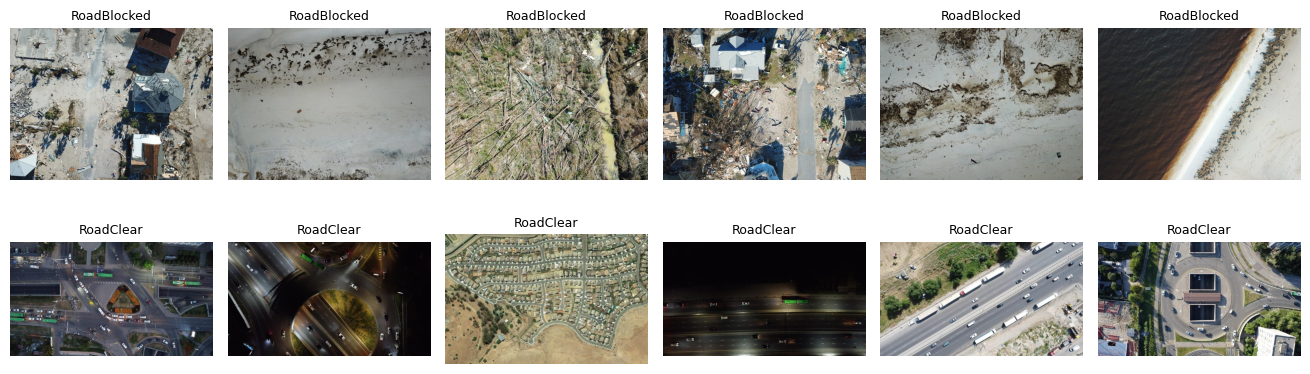

In [ ]:
def show_samples(data_dir, samples_per_class=6):
    class_dirs = sorted([p for p in data_dir.iterdir() if p.is_dir()])
    fig, axes = plt.subplots(len(class_dirs), samples_per_class, figsize=(samples_per_class * 2.2, len(class_dirs) * 2.2))
    if len(class_dirs) == 1:
        axes = np.array([axes])

    for row, class_dir in enumerate(class_dirs):
        files = [p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
        chosen = random.sample(files, min(samples_per_class, len(files)))
        for col in range(samples_per_class):
            ax = axes[row, col]
            ax.axis('off')
            if col < len(chosen):
                img = Image.open(chosen[col]).convert('RGB')
                ax.imshow(img)
                ax.set_title(class_dir.name, fontsize=9)
    plt.tight_layout()
    plt.show()

show_samples(CLEAN_DATA_DIR)

In [ ]:
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

full_dataset_for_split = datasets.ImageFolder(CLEAN_DATA_DIR, transform=base_transform)
class_names = full_dataset_for_split.classes
class_to_idx = full_dataset_for_split.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

targets = np.array(full_dataset_for_split.targets)
indices = np.arange(len(full_dataset_for_split))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=targets,
    random_state=SEED,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=targets[temp_idx],
    random_state=SEED,
)

for split_name, split_idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    counts = pd.Series(targets[split_idx]).map(idx_to_class).value_counts()
    print('\n' + split_name)
    print(counts)


train
RoadBlocked    2516
RoadClear      1309
Name: count, dtype: int64

val
RoadBlocked    539
RoadClear      281
Name: count, dtype: int64

test
RoadBlocked    540
RoadClear      280
Name: count, dtype: int64


In [ ]:
if MODEL_NAME == 'convnext_tiny':
    weights = ConvNeXt_Tiny_Weights.DEFAULT
    normalize = weights.transforms()
elif MODEL_NAME == 'resnet50':
    weights = ResNet50_Weights.DEFAULT
    normalize = weights.transforms()
else:
    raise ValueError(f'Unknown MODEL_NAME: {MODEL_NAME}')

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize.mean, std=normalize.std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize.mean, std=normalize.std),
])

train_dataset_full = datasets.ImageFolder(CLEAN_DATA_DIR, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(CLEAN_DATA_DIR, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(eval_dataset_full, val_idx)
test_dataset = Subset(eval_dataset_full, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)



In [ ]:
def build_model(model_name, num_classes):
    if model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_model(MODEL_NAME, num_classes=len(class_names)).to(DEVICE)
print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


ResNet


In [ ]:
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=len(class_names))
class_weights = len(train_targets) / (len(class_names) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class counts:', {idx_to_class[i]: int(c) for i, c in enumerate(class_counts)})
print('Class weights:', {idx_to_class[i]: float(w) for i, w in enumerate(class_weights.detach().cpu())})

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

Class counts: {'RoadBlocked': 2516, 'RoadClear': 1309}
Class weights: {'RoadBlocked': 0.7601351141929626, 'RoadClear': 1.4610389471054077}


/tmp/ipykernel_972/1518378896.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


In [ ]:
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average='binary' if len(class_names) == 2 else 'macro',
        zero_division=0,
    )

    try:
        if len(class_names) == 2:
            positive_idx = class_to_idx.get('RoadBlocked', 1)
            auc = roc_auc_score(all_labels, np.array(all_probs)[:, positive_idx])
        else:
            auc = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr')
    except Exception:
        auc = np.nan

    return {
        'loss': avg_loss,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': auc,
        'labels': np.array(all_labels),
        'preds': np.array(all_preds),
        'probs': np.array(all_probs),
    }

In [ ]:
best_val_f1 = -1
best_path = MODELS_DIR / f'{MODEL_NAME}_roads_best.pth'
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_one_epoch(model, val_loader, optimizer=None)
    scheduler.step()

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_precision': train_metrics['precision'],
        'train_recall': train_metrics['recall'],
        'train_f1': train_metrics['f1'],
        'train_roc_auc': train_metrics['roc_auc'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_f1': val_metrics['f1'],
        'val_roc_auc': val_metrics['roc_auc'],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train acc {row['train_accuracy']:.4f} f1 {row['train_f1']:.4f} loss {row['train_loss']:.4f} | "
        f"val acc {row['val_accuracy']:.4f} f1 {row['val_f1']:.4f} loss {row['val_loss']:.4f}"
    )

    if row['val_f1'] > best_val_f1:
        best_val_f1 = row['val_f1']
        checkpoint = {
            'model_name': MODEL_NAME,
            'state_dict': model.state_dict(),
            'image_size': IMAGE_SIZE,
            'class_names': list(class_names),
            'class_to_idx': dict(class_to_idx),
            'idx_to_class': {int(k): v for k, v in idx_to_class.items()},
            'best_val_f1': float(best_val_f1),
            'epoch': int(epoch),
        }
        torch.save(checkpoint, best_path)
        print('Saved best model to:', best_path)

history_df = pd.DataFrame(history)
history_csv = RESULTS_DIR / f'{MODEL_NAME}_roads_history.csv'
history_df.to_csv(history_csv, index=False)
print('Saved history to:', history_csv)
history_df

/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 01/12 | train acc 0.9898 f1 0.9852 loss 0.0732 | val acc 1.0000 f1 1.0000 loss 0.0014
Saved best model to: /content/drive/MyDrive/NatDisaster/models_roads/resnet50_roads_best.pth


/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 02/12 | train acc 0.9995 f1 0.9992 loss 0.0041 | val acc 1.0000 f1 1.0000 loss 0.0011


/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


...

/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 11/12 | train acc 1.0000 f1 1.0000 loss 0.0001 | val acc 1.0000 f1 1.0000 loss 0.0001


/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 12/12 | train acc 1.0000 f1 1.0000 loss 0.0001 | val acc 1.0000 f1 1.0000 loss 0.0001
Saved history to: /content/drive/MyDrive/NatDisaster/results_roads/resnet50_roads_history.csv


,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.073186,0.989804,0.979607,0.990833,0.985188,2.895146e-04,0.001434,1.0,1.0,1.0,1.0,0.0
1,2,0.004113,0.999477,0.999236,0.999236,0.999236,3.947236e-06,0.001131,1.0,1.0,1.0,1.0,0.0
2,3,0.001631,0.999739,0.999237,1.000000,0.999618,3.036335e-07,0.000533,1.0,1.0,1.0,1.0,0.0
3,4,0.000819,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000238,1.0,1.0,1.0,1.0,0.0
4,5,0.000386,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000096,1.0,1.0,1.0,1.0,0.0
5,6,0.000516,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000112,1.0,1.0,1.0,1.0,0.0
6,7,0.000220,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000106,1.0,1.0,1.0,1.0,0.0
7,8,0.000188,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000082,1.0,1.0,1.0,1.0,0.0
8,9,0.000098,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000088,1.0,1.0,1.0,1.0,0.0
9,10,0.000185,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000074,1.0,1.0,1.0,1.0,0.0


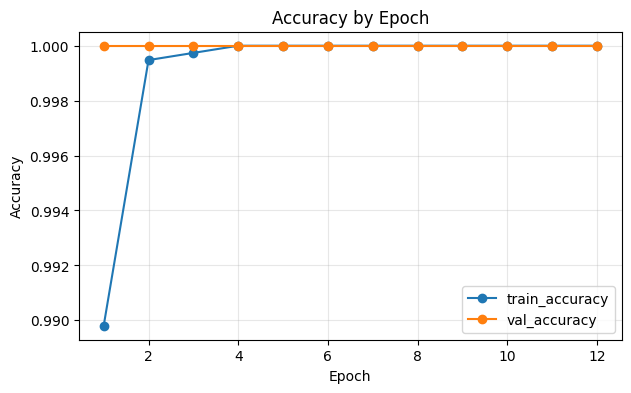

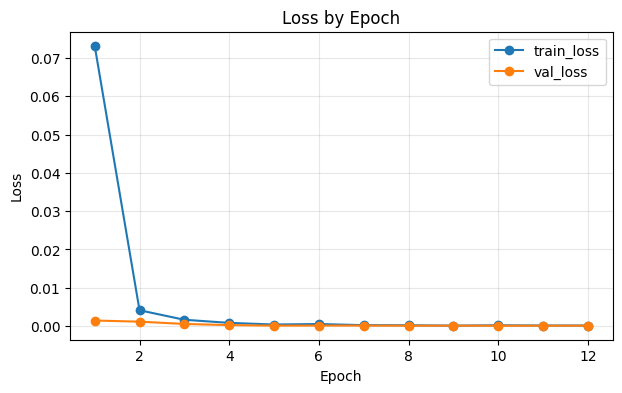

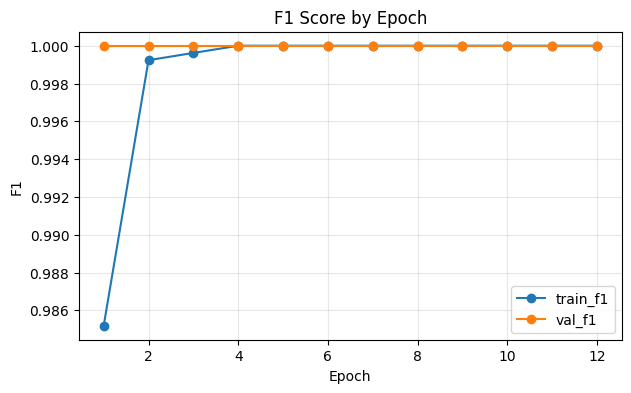

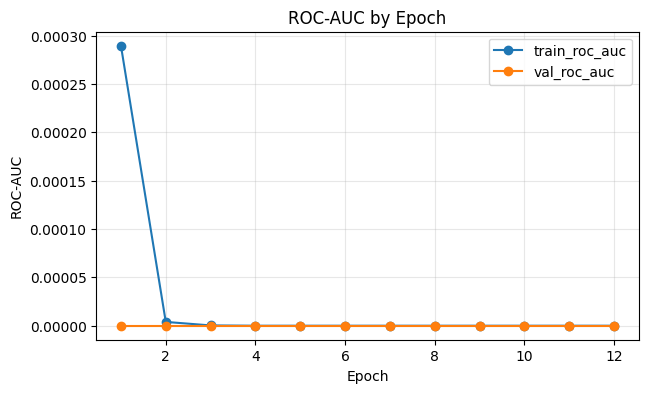

In [ ]:
def plot_metric(history_df, train_col, val_col, title, ylabel):
    plt.figure(figsize=(7, 4))
    plt.plot(history_df['epoch'], history_df[train_col], marker='o', label=train_col)
    plt.plot(history_df['epoch'], history_df[val_col], marker='o', label=val_col)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(history_df, 'train_accuracy', 'val_accuracy', 'Accuracy by Epoch', 'Accuracy')
plot_metric(history_df, 'train_loss', 'val_loss', 'Loss by Epoch', 'Loss')
plot_metric(history_df, 'train_f1', 'val_f1', 'F1 Score by Epoch', 'F1')
plot_metric(history_df, 'train_roc_auc', 'val_roc_auc', 'ROC-AUC by Epoch', 'ROC-AUC')

In [ ]:
checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
model = build_model(checkpoint['model_name'], num_classes=len(checkpoint['class_names'])).to(DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

# Keep these from the checkpoint, in case the class order differs later.
class_names = checkpoint['class_names']
class_to_idx = checkpoint['class_to_idx']
idx_to_class = {int(k): v for k, v in checkpoint['idx_to_class'].items()}

test_metrics = run_one_epoch(model, test_loader, optimizer=None)

print('TEST METRICS')
print('Accuracy:', round(test_metrics['accuracy'], 4))
print('Precision:', round(test_metrics['precision'], 4))
print('Recall:', round(test_metrics['recall'], 4))
print('F1:', round(test_metrics['f1'], 4))
print('ROC-AUC:', round(test_metrics['roc_auc'], 4))
print()
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=class_names, zero_division=0))

/tmp/ipykernel_972/4096994175.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


TEST METRICS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 0.0

              precision    recall  f1-score   support

 RoadBlocked       1.00      1.00      1.00       540
   RoadClear       1.00      1.00      1.00       280

    accuracy                           1.00       820
   macro avg       1.00      1.00      1.00       820
weighted avg       1.00      1.00      1.00       820



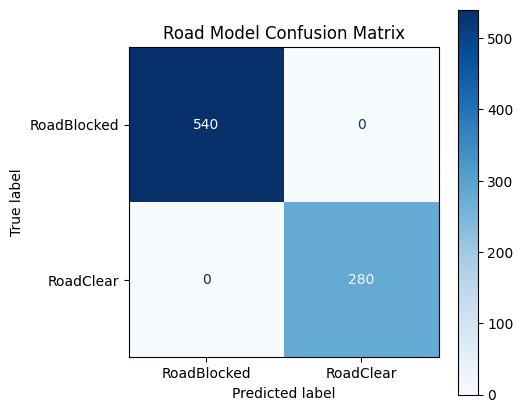

Saved confusion matrix to: /content/drive/MyDrive/NatDisaster/results_roads/resnet50_roads_confusion_matrix.png


In [ ]:
cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Road Model Confusion Matrix')
plt.show()

cm_path = RESULTS_DIR / f'{MODEL_NAME}_roads_confusion_matrix.png'
fig.savefig(cm_path, dpi=200, bbox_inches='tight')
print('Saved confusion matrix to:', cm_path)

In [ ]:
final_export_path = MODELS_DIR / f'{MODEL_NAME}_road_access.pth'

safe_test_metrics = {
    'accuracy': float(test_metrics['accuracy']),
    'precision': float(test_metrics['precision']),
    'recall': float(test_metrics['recall']),
    'f1': float(test_metrics['f1']),
    'roc_auc': float(test_metrics['roc_auc']) if not np.isnan(test_metrics['roc_auc']) else None,
}

export_checkpoint = {
    'model_name': checkpoint['model_name'],
    'state_dict': checkpoint['state_dict'],
    'image_size': int(checkpoint['image_size']),
    'class_names': list(checkpoint['class_names']),
    'class_to_idx': dict(checkpoint['class_to_idx']),
    'idx_to_class': {int(k): v for k, v in checkpoint['idx_to_class'].items()},
    'test_metrics': safe_test_metrics,
}

torch.save(export_checkpoint, final_export_path)
print('Exported road access model to:', final_export_path)
print('Test metrics:', safe_test_metrics)

Exported road access model to: /content/drive/MyDrive/NatDisaster/models_roads/resnet50_road_access.pth
Test metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 0.0}
